In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# %matplotlib inline
import  matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.sans-serif']='Times New Roman'

In [3]:
train= pd.read_excel('../dataset/pre_train.xlsx')
test= pd.read_excel('../dataset/pre_test.xlsx')

In [4]:
X_columns = [col for col in train.columns if col not in ['time','AQ']]
Y_columns =['AQ']

In [5]:
x_train=train[X_columns]
y_train=train[Y_columns]
x_test=test[X_columns]
y_test=test[Y_columns]

In [6]:
import joblib
import os

file_dir = "..\goaldata"
mpkl_name=[]
mpkl_path=[]
# 获得文件完整路径
for root, dirs, files in os.walk(file_dir):
    for name in files:
        mpkl_name.append(str(name)[:-5].upper())
        mpkl_path.append(os.path.join(root, name))

import re
def sortkey(element):
    a=re.findall("\d+",element)
    return int(*a)


mpkl_name.sort(key=sortkey, reverse=False)
print(mpkl_name)

mpkl_path.sort(key=sortkey, reverse=False)
print(mpkl_path)


['M1_ROBUST', 'M2_SVM', 'M3_DT', 'M4_KNN', 'M5_ANN', 'M6_LSTM', 'M7_HUBER', 'M8_BAYES', 'M9_LGBM', 'M10_GBDT', 'M11_XGB', 'M12_RF']
['..\\goaldata\\m1_Robust.xlsx', '..\\goaldata\\m2_svm.xlsx', '..\\goaldata\\m3_dt.xlsx', '..\\goaldata\\m4_knn.xlsx', '..\\goaldata\\m5_ANN.xlsx', '..\\goaldata\\m6_LSTM.xlsx', '..\\goaldata\\m7_Huber.xlsx', '..\\goaldata\\m8_bayes.xlsx', '..\\goaldata\\m9_LGBM.xlsx', '..\\goaldata\\m10_GBDT.xlsx', '..\\goaldata\\m11_XGB.xlsx', '..\\goaldata\\m12_RF.xlsx']


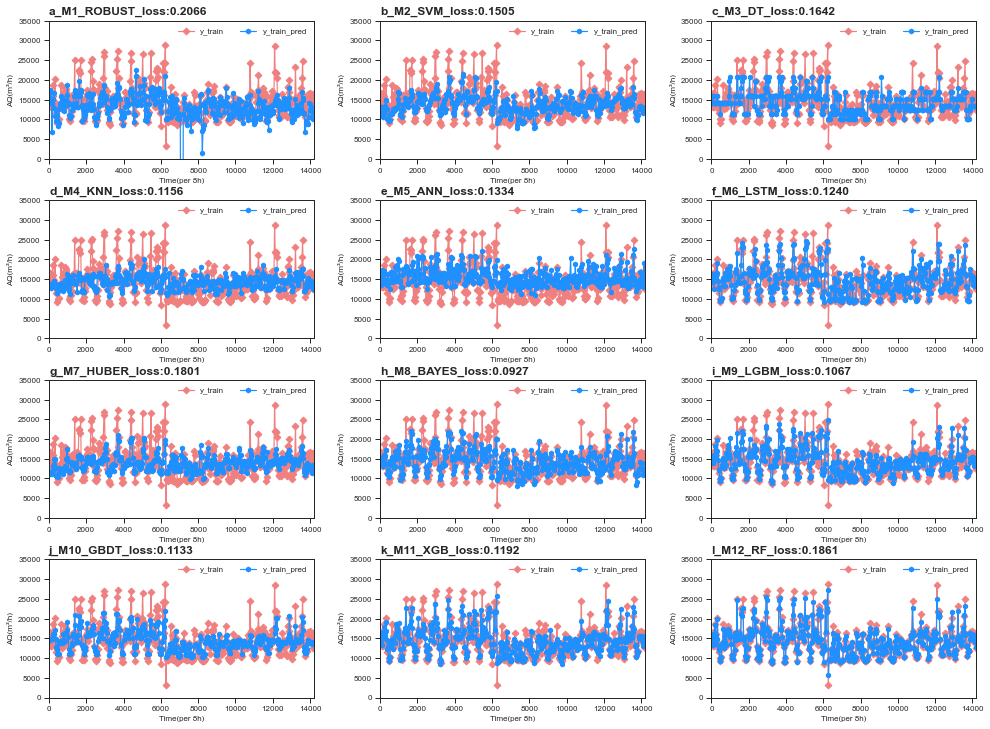

In [16]:
import joblib
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
sns.set(context='paper', style='ticks')

fig,axes=plt.subplots(4,3,figsize=(14,10))
a=1
dict_axes={}
for i in range(5):
    for j in range(3):
        dict_axes[a]=[i,j]
        a=a+1

def plttrain(mpkl_name,num):
    i=num-1
    name=str(mpkl_name[i])
    pdata=pd.read_excel(mpkl_path[i])


    y_pred = pdata['ytest'].dropna(axis=0)
    loss=mean_absolute_percentage_error(y_test, y_pred)


    train_index=train.index
    y_train_pred=pdata['ytrain']
    y_train_pred=pd.DataFrame(columns=['AQ'],data=np.array(y_train_pred))

    ax=axes[dict_axes[num][0]][dict_axes[num][1]]

    fig.subplots_adjust(left=0.05, right=0.97, bottom=0.04, top=0.98, wspace=0.25, hspace=0.3)
    x=train_index[::32]
    y1=y_train['AQ'][::32]
    y2=y_train_pred['AQ'][::32]
    lns1=ax.plot(x,y1,label='y_train',marker='D',markevery=1, color='lightcoral')
    lns2=ax.plot(x,y2,label='y_train_pred',marker='h',markevery=1, color='dodgerblue')
    ax.tick_params(labelsize=8)
    ax.set_xlim(0,14208,2000)
    ax.set_ylim(0,35000, 5000)
    ax.set_xlabel('Time(per 8h)',size=8)
    ax.set_ylabel('AQ(m³/h)',size=8)
    alphabet=['a','b','c','d','e','f','g','h','i','j','k','l']
    ax.set_title(f'{alphabet[i]}_{name}_loss:{loss:.4f}',size=12,fontweight='bold',loc='left')
    lns = lns1+lns2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=1,fontsize=8,ncol=2,frameon=False)
plttrain(mpkl_name,1)
plttrain(mpkl_name,2)
plttrain(mpkl_name,3)
plttrain(mpkl_name,4)
plttrain(mpkl_name,5)
plttrain(mpkl_name,6)
plttrain(mpkl_name,7)
plttrain(mpkl_name,8)
plttrain(mpkl_name,9)
plttrain(mpkl_name,10)
plttrain(mpkl_name,11)
plttrain(mpkl_name,12)
plt.savefig('F:/fig/figS2.tiff', dpi=600)
plt.show()



In [8]:
loss_evl=pd.DataFrame(columns=['modelname','MAPE', 'R2', 'RMSE'], index=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
loss_evl

,modelname,MAPE,R2,RMSE
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


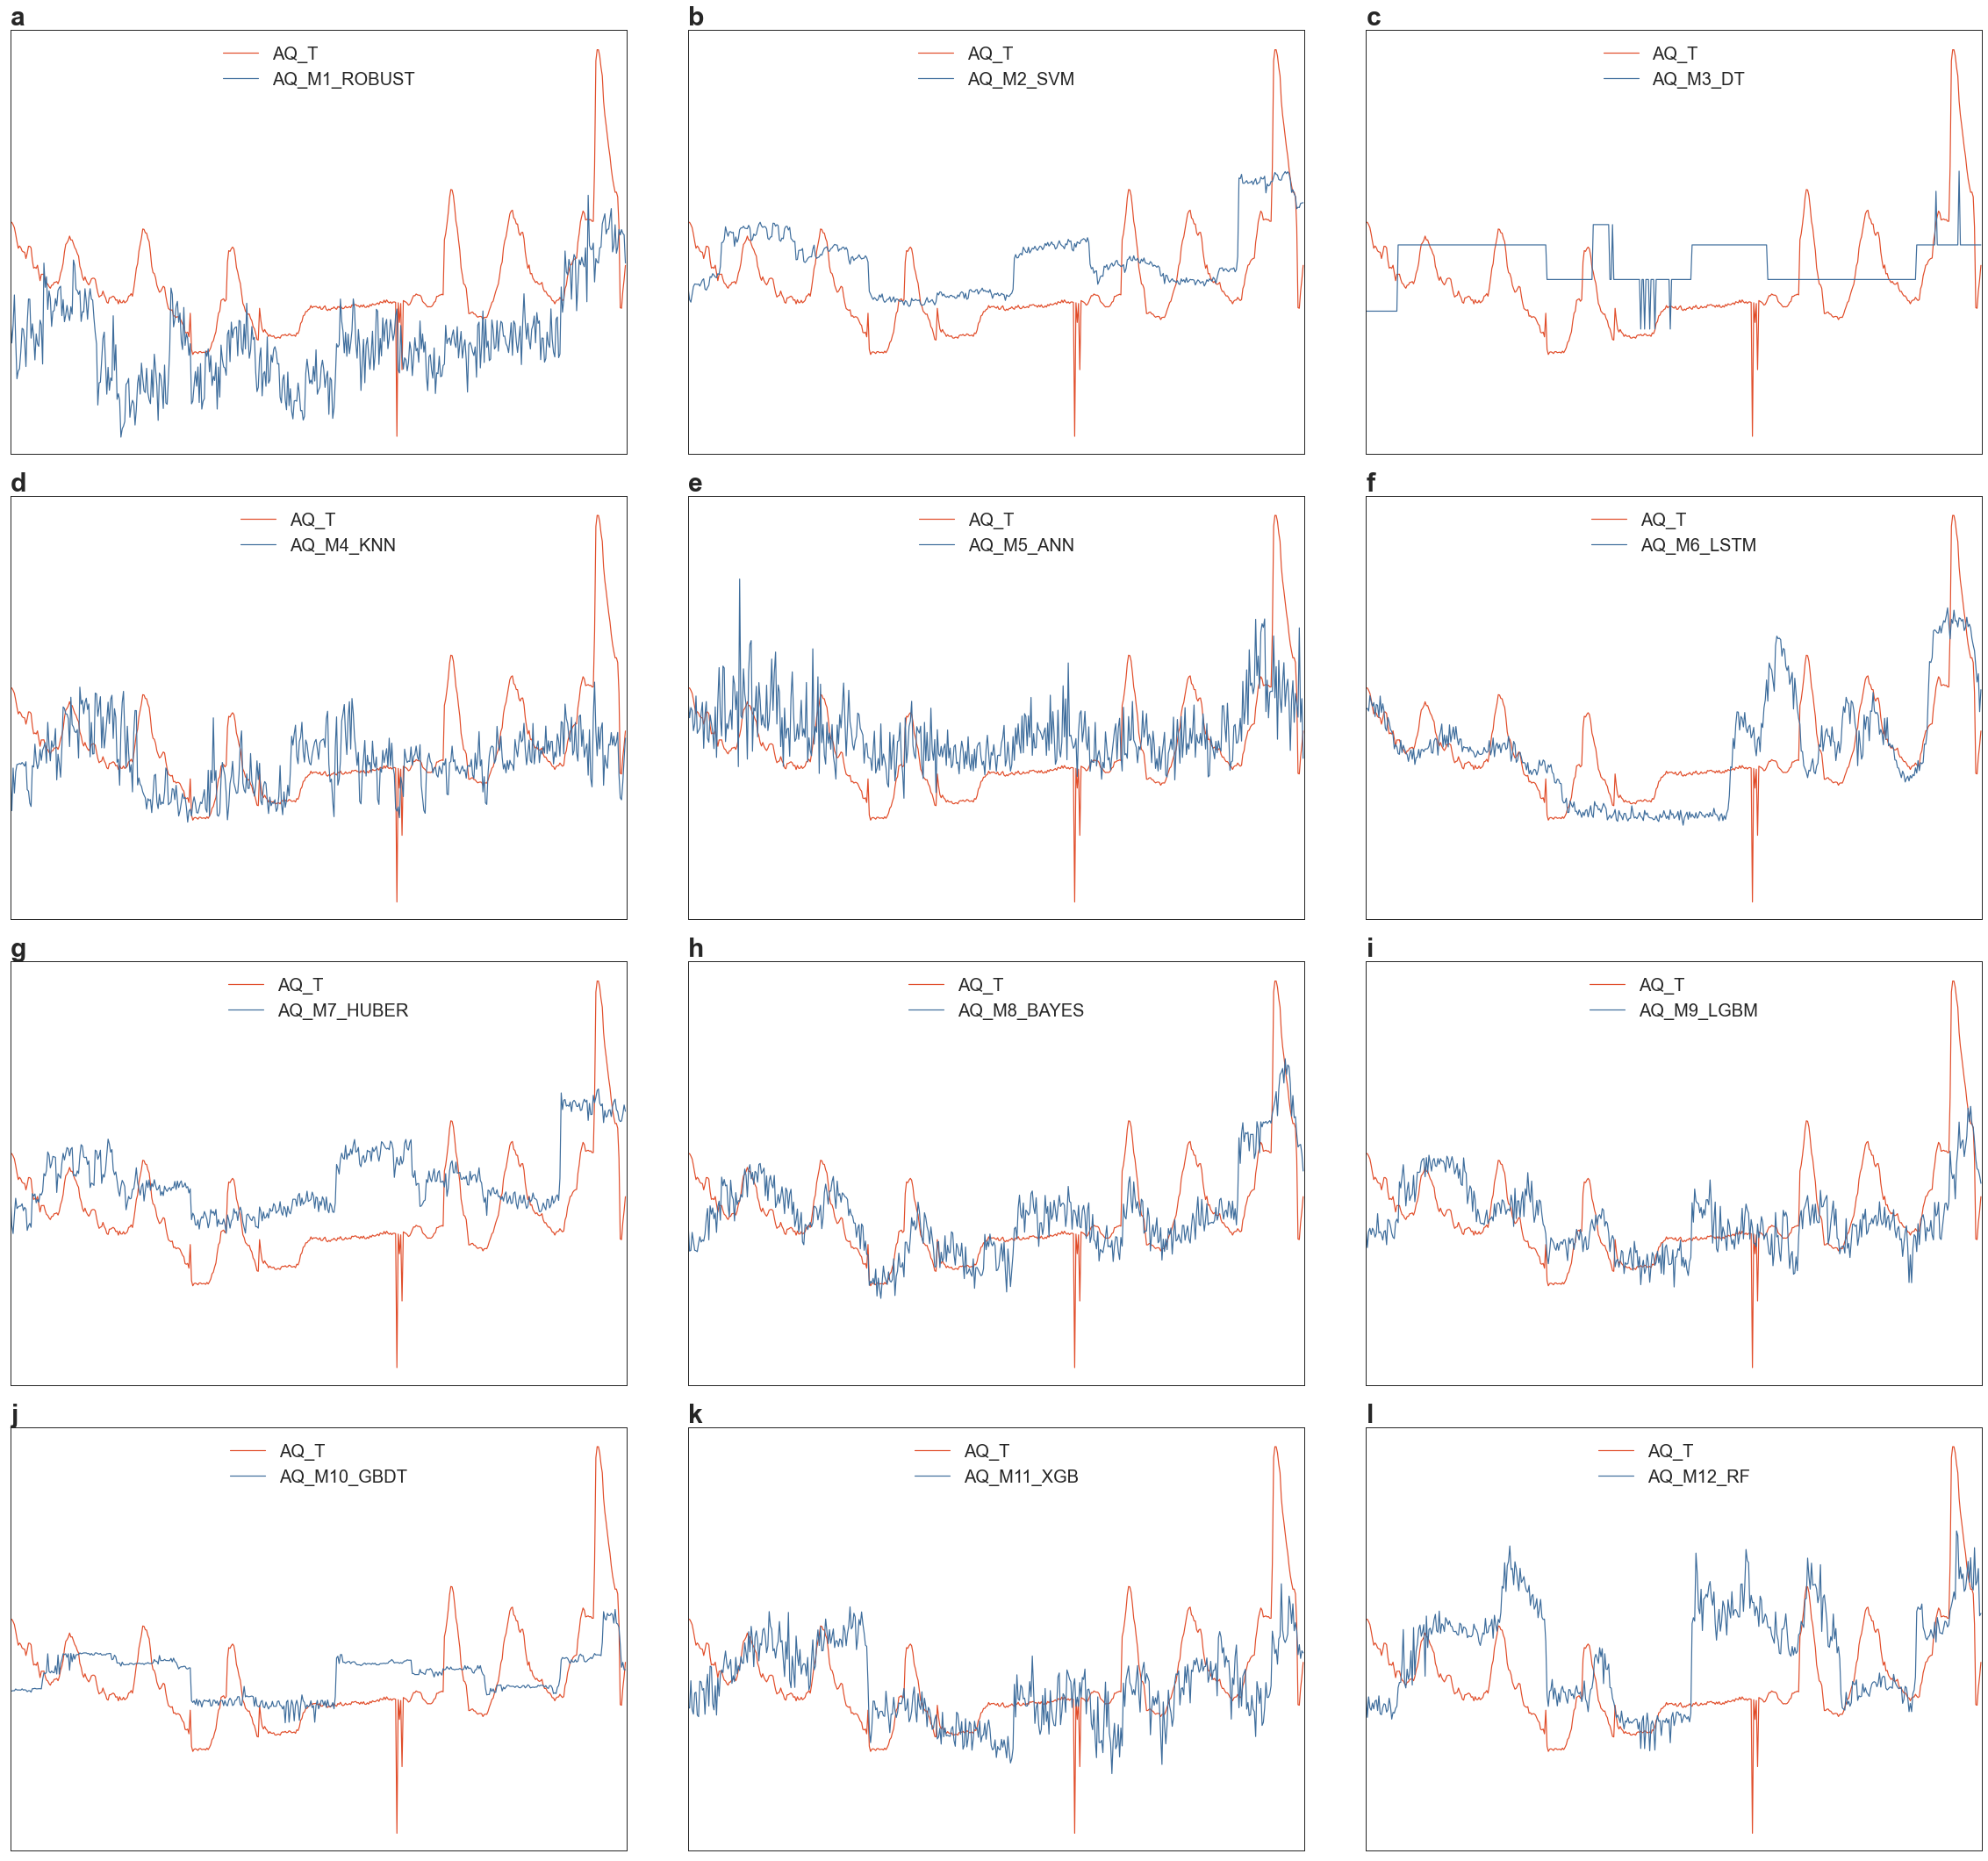

In [9]:
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import r2_score as r2

from sklearn.metrics import mean_squared_error as mse



fig,axes=plt.subplots(4,3,figsize=(39,36))


a=1
dict_axes={}
for i in range(5):
    for j in range(3):
        dict_axes[a]=[i,j]
        a=a+1


def plttest(mpkl_name,num):
    i=num-1
    name=str(mpkl_name[i])
    pdata=pd.read_excel(mpkl_path[i])

    y_pred = pdata['ytest'].dropna(axis=0)
    loss=mape(y_test, y_pred)
    r2loss=r2(y_test, y_pred)
    rmse=mse(y_test, y_pred)**0.5
    modelname=f'{name}'
    loss_evl.iloc[i,0]=modelname
    loss_evl.iloc[i,1]=loss
    loss_evl.iloc[i,2]=r2loss
    loss_evl.iloc[i,3]=rmse

    test_index=test.index
    y_test_pred=pdata['ytest'].dropna(axis=0)
    y_test_pred=pd.DataFrame(columns=['AQ'],data=np.array(y_test_pred))


    ax=axes[dict_axes[num][0]][dict_axes[num][1]]
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)

    x=test_index
    y1=y_test['AQ']
    y2=y_test_pred['AQ']
    ax.xaxis.set_visible(False) # 隐藏x坐标轴
    ax.yaxis.set_visible(False) # 隐藏y坐标轴
    lns1=ax.plot(x,y1,label='AQ_T', color='#E14D2A')
    # marker='D',markevery=3,
    lns2=ax.plot(x,y2,label=f'AQ_{name}', color='#3E6D9C')

    # marker='h',markevery=3,
    # ax.tick_params(labelsize=12)
    ax.set_xlim(0,480,96)
    ax.set_ylim(6000,28000,1000)
    # ax.set_xlabel(f'{name}',size=20)
    # ax.set_xlabel('Timeindex(8h)',size=20)
    # ax.set_ylabel('AQ(m³/h)',size=20)

    alphabet=['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o']
    ax.set_title(f'{alphabet[i]}',size=30,fontweight='bold',loc='left')
    # ax.set_title(f'{name}_loss:{loss:.4f}',size=20,fontweight='bold',loc='left')

    lns = lns1+lns2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=9,fontsize=20,ncol=1,frameon=False)


plttest(mpkl_name,1)
plttest(mpkl_name,2)
plttest(mpkl_name,3)
plttest(mpkl_name,4)
plttest(mpkl_name,5)
plttest(mpkl_name,6)
plttest(mpkl_name,7)
plttest(mpkl_name,8)
plttest(mpkl_name,9)
plttest(mpkl_name,10)
plttest(mpkl_name,11)
plttest(mpkl_name,12)




In [10]:
loss_evl

,modelname,MAPE,R2,RMSE
0,M1_ROBUST,0.206638,-1.237988,3732.456615
1,M2_SVM,0.150521,-0.013452,2511.698686
2,M3_DT,0.164249,-0.273179,2815.208645
3,M4_KNN,0.115626,-0.128573,2650.517428
4,M5_ANN,0.133381,0.025554,2462.888333
5,M6_LSTM,0.123964,0.118118,2342.994248
6,M7_HUBER,0.180094,-0.376203,2926.894734
7,M8_BAYES,0.092688,0.438251,1869.980414
8,M9_LGBM,0.10674,0.22197,2200.716679
9,M10_GBDT,0.113288,0.206935,2221.878005


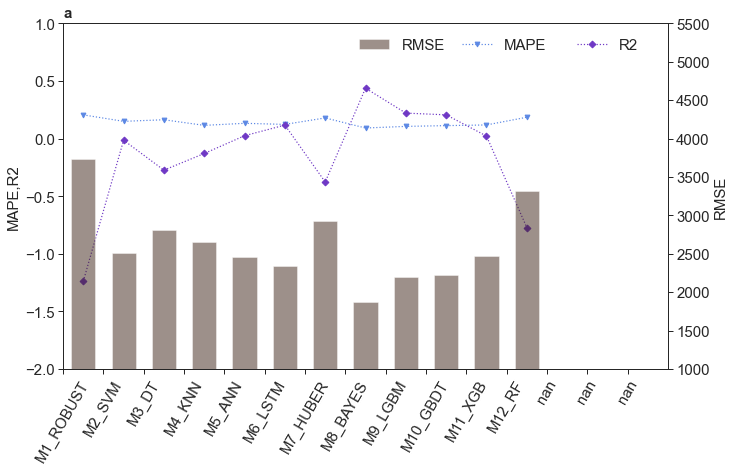

In [11]:
import seaborn as sns
sns.set(context='paper', style='ticks')


fig,axes=plt.subplots(1,1,figsize=(12,6))
ax1=axes

fig.subplots_adjust(left=0.1, right=0.8, bottom=0.1, top=0.9, wspace=0.2, hspace=0.3)
xran=[i-0.5 for i in range(15)]


x=loss_evl.index

y1=loss_evl['MAPE']
y2=loss_evl['R2']
y3=loss_evl['RMSE']
plt.xticks(ticks=xran,labels=loss_evl['modelname'],rotation=60,fontsize=15)
plt.yticks(rotation=0,fontsize=15)
lns1=ax1.plot(x,y1,label='MAPE',marker='v',markevery=1, color='#5C88E4',linestyle='dotted')

lns2=ax1.plot(x,y2,label='R2',marker='D',markevery=1, color='#6F38C5',linestyle='dotted')
# darkorange
# royalblue
ax_r =ax1.twinx()
lns3=ax_r.bar(x,y3,label='RMSE',width=0.6,color='#3C2317',alpha=0.5)
plt.legend(loc=(0.48,0.9),fontsize=15,frameon=False)
plt.yticks(rotation=0,fontsize=15)



# plt.xticks(rotation=45,labelsize=12)
# # ax1.tick_params(rotation=45,labelsize=12)
# ax_r.tick_params(labelsize=12)

ax1.set_xlim(-0.5,14.5,1)
ax1.set_ylim(-2,1, 0.5)
ax_r.set_ylim(1000,5500, 500)
# ax1.set_xlabel('modelname',size=30)
ax1.set_ylabel('MAPE,R2',size=15)
ax_r.set_ylabel('RMSE',size=15)
ax1.set_title('a',size=15,fontweight='bold',loc='left')
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=(0.65,0.9),fontsize=15,ncol=2,frameon=False)

